# Horizontal Variability Analysis of Petrophysical Maps
## Five-property geological study: Structure · Porosity · Isopach · Water Saturation · Gamma Ray

This notebook implements five spatial analysis methods:
1. **Cross-correlation & spatial autocovariance**
2. **Variogram modeling & geostatistical characterization**
3. **Principal Component Analysis (PCA)**
4. **Moving-window statistics & trend surface analysis**
5. **Cluster analysis (K-means electrofacies)**


## 0. Setup & synthetic map generation
We reproduce the same five property grids used in the interactive maps, then apply each analytical method in turn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

GRID = 80   # grid resolution (GRID+1 x GRID+1 nodes)
np.random.seed(42)


In [2]:
# ── Shared base field (same spatial structure as the interactive maps) ─────────
def base_field(nx, ny):
    return (
        0.42 * np.sin(nx*np.pi*1.2+0.3) * np.cos(ny*np.pi*0.9+0.5) +
        0.28 * np.sin(nx*np.pi*2.1+1.1) * np.sin(ny*np.pi*1.7+0.8) +
        0.18 * np.cos(nx*np.pi*3.0+0.7) * np.cos(ny*np.pi*2.5+1.3) +
        0.08 * np.sin(nx*np.pi*4.0+2.0) * np.cos(ny*np.pi*3.8+0.4) +
        0.14 * (1 - np.exp(-((nx-0.30)**2+(ny-0.25)**2)/0.015)) -
        0.11 * np.exp(-((nx-0.72)**2+(ny-0.68)**2)/0.012)
    )

x = np.linspace(0, 1, GRID+1)
y = np.linspace(0, 1, GRID+1)
NX, NY = np.meshgrid(x, y)   # shape (81,81)
BF     = base_field(NX, NY)

# ── Five property grids ────────────────────────────────────────────────────────
struct = 7500 + 900*np.sin(NX*np.pi*1.2+0.3)*np.cos(NY*np.pi*0.9+0.5)               + 600*np.sin(NX*np.pi*2.1+1.1)*np.sin(NY*np.pi*1.7+0.8)               + 400*np.cos(NX*np.pi*3.0+0.7)*np.cos(NY*np.pi*2.5+1.3)               + 200*np.sin(NX*np.pi*4.0+2.0)*np.cos(NY*np.pi*3.8+0.4)               + 300*(1-np.exp(-((NX-0.30)**2+(NY-0.25)**2)/0.015))               - 250*np.exp(-((NX-0.72)**2+(NY-0.68)**2)/0.012)
struct = np.clip(struct, 7500, 10000)

poro = np.clip(0.075 + 0.025*BF, 0.05, 0.10)
iso  = np.clip(40 + 20*(-BF*0.9 + 0.05*np.sin(NX*5)*np.cos(NY*4)), 20, 60)
sw   = np.clip(0.40 - 0.18*BF + 0.04*np.cos(NX*6+NY*4), 0.20, 0.60)
gr   = np.clip(75 + 42*(BF*0.8 + 0.12*np.sin(NX*7+1)*np.sin(NY*5+0.5)), 30, 120)

maps   = dict(Structure=struct, Porosity=poro, Isopach=iso, Sw=sw, GR=gr)
cmaps  = dict(Structure='RdYlGn_r', Porosity='Blues', Isopach='YlOrBr',
              Sw='RdBu_r', GR='Purples')
units  = dict(Structure='ft', Porosity='frac', Isopach='ft', Sw='frac', GR='API')

print("Grid shape:", struct.shape)
print({k: f"{v.min():.3g} – {v.max():.3g}" for k,v in maps.items()})


Grid shape: (81, 81)
{'Structure': '7.5e+03 – 8.98e+03', 'Porosity': '0.0648 – 0.092', 'Isopach': '28.4 – 46.6', 'Sw': '0.248 – 0.467', 'GR': '58 – 102'}


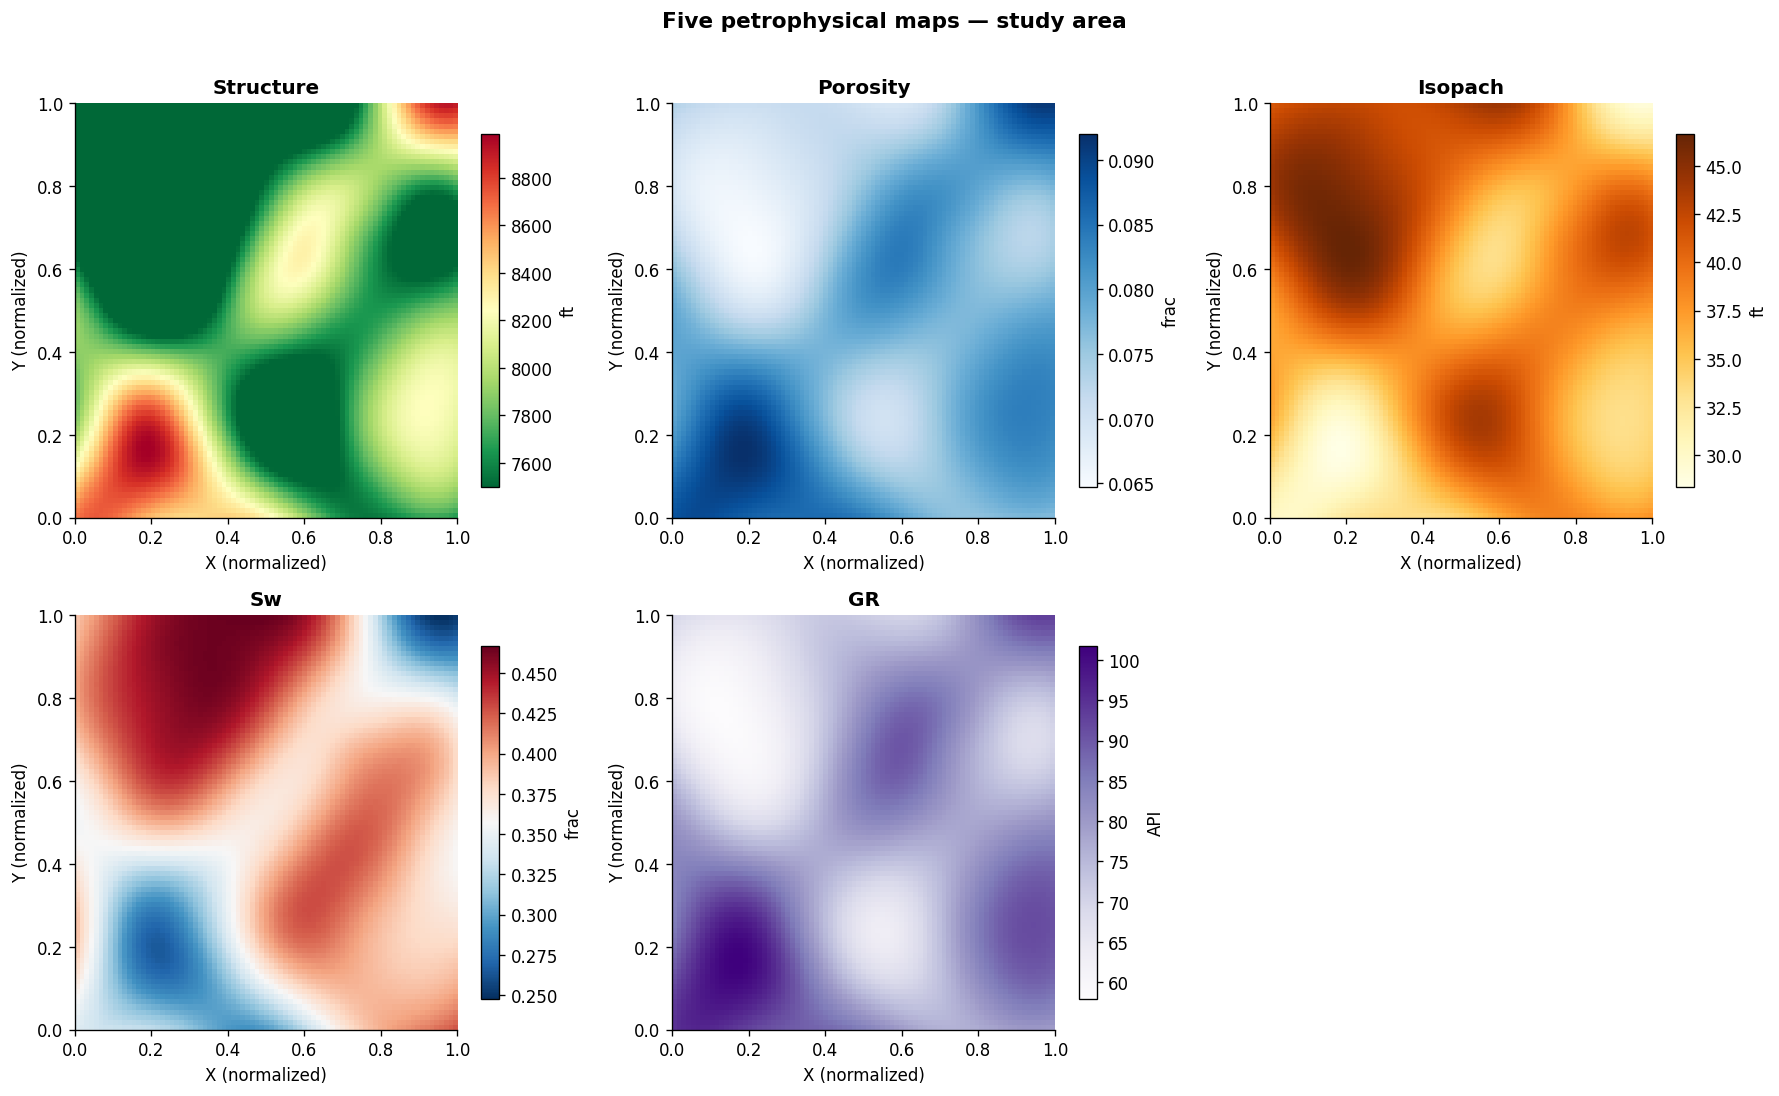

In [3]:
# ── Quick overview of all five maps ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, (name, grid) in zip(axes, maps.items()):
    im = ax.imshow(grid, origin='lower', cmap=cmaps[name],
                   extent=[0,1,0,1], aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85,
                 label=units[name])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('X (normalized)'); ax.set_ylabel('Y (normalized)')
axes[-1].set_visible(False)
plt.suptitle('Five petrophysical maps — study area', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('00_all_maps.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Method 1 — Cross-correlation & spatial autocovariance

### 1-A  Pairwise Pearson & Spearman correlation matrix
Flatten each grid to a 1-D vector and compute both correlation coefficients across all pairs.


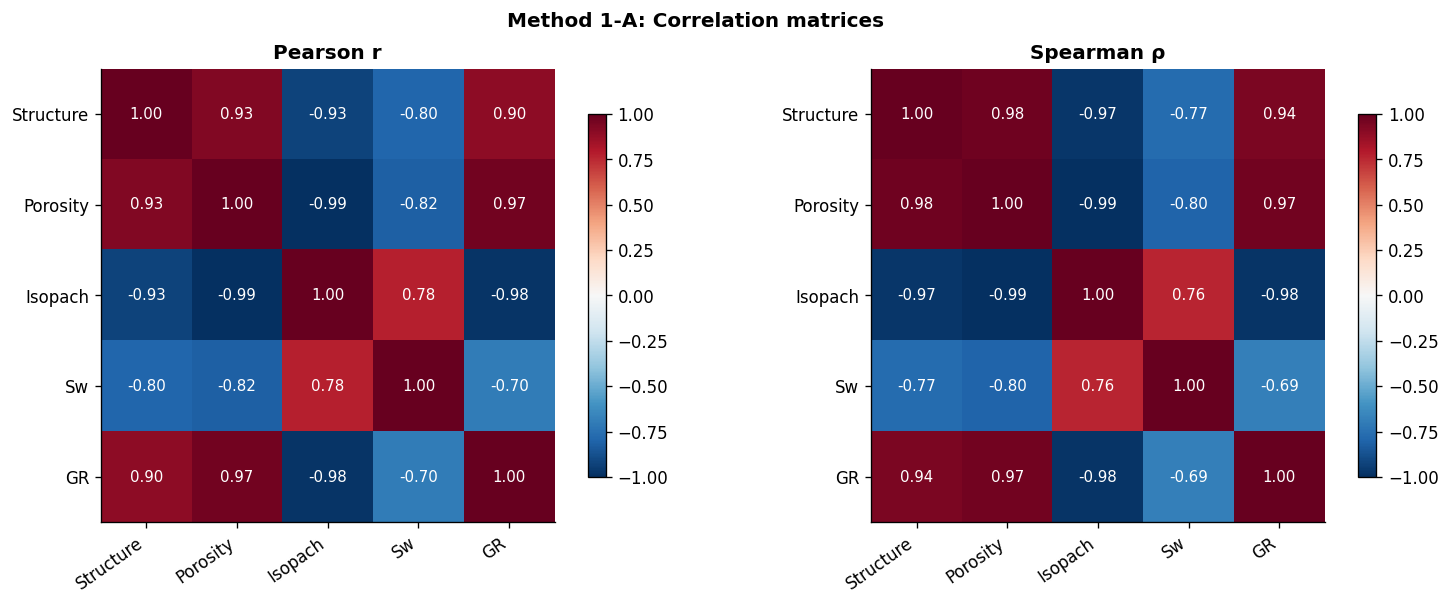

In [4]:
# Flatten grids to vectors
props = list(maps.keys())
flat  = {k: v.ravel() for k,v in maps.items()}
df    = pd.DataFrame(flat)

pearson  = df.corr(method='pearson')
spearman = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, mat) in zip(axes, [('Pearson r', pearson), ('Spearman ρ', spearman)]):
    im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(props))); ax.set_yticks(range(len(props)))
    ax.set_xticklabels(props, rotation=35, ha='right')
    ax.set_yticklabels(props)
    for i in range(len(props)):
        for j in range(len(props)):
            ax.text(j, i, f'{mat.values[i,j]:.2f}',
                    ha='center', va='center', fontsize=9,
                    color='white' if abs(mat.values[i,j]) > 0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontweight='bold')
plt.suptitle('Method 1-A: Correlation matrices', fontweight='bold')
plt.tight_layout()
plt.savefig('01a_correlation_matrix.png', dpi=130, bbox_inches='tight')
plt.show()


### 1-B  Spatial autocorrelogram (Moran's I by lag distance)
Measure how each property's spatial autocorrelation decays with increasing separation distance.

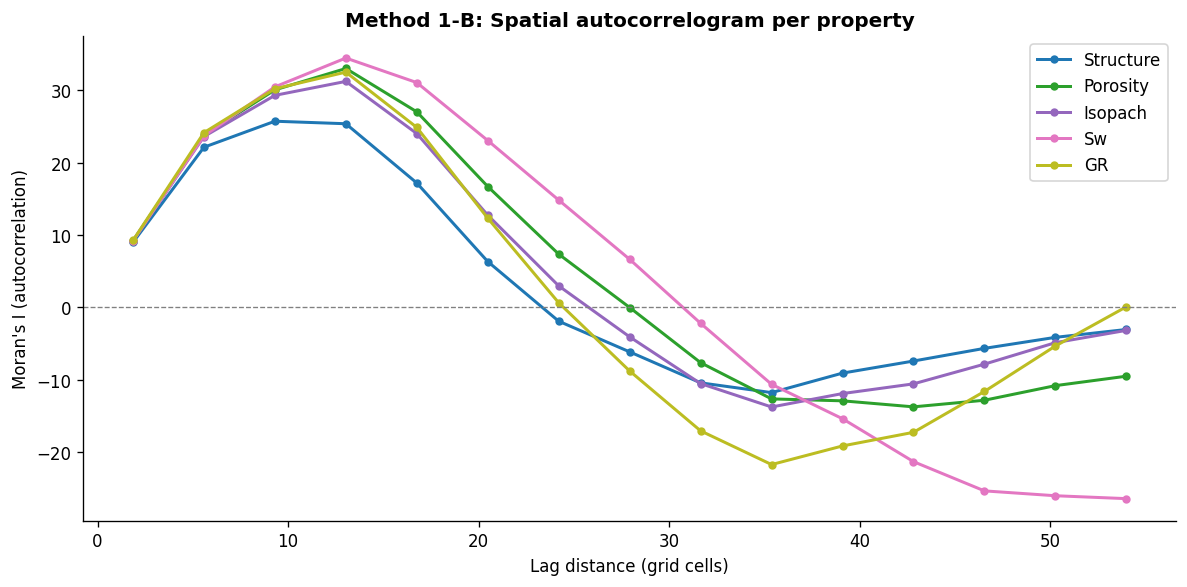

In [5]:
def morans_I_by_lag(grid, n_lags=15, max_lag_frac=0.5):
    """Compute Moran's I as a function of lag distance (isotropic)."""
    flat = grid.ravel()
    rows, cols = grid.shape
    # sample a subset for speed
    rng = np.random.default_rng(0)
    idx = rng.choice(len(flat), size=min(1500, len(flat)), replace=False)
    r_idx, c_idx = np.unravel_index(idx, grid.shape)
    coords = np.stack([r_idx, c_idx], axis=1).astype(float)
    vals   = flat[idx]
    vals_c = vals - vals.mean()
    dists  = squareform(pdist(coords))
    max_d  = dists.max() * max_lag_frac
    lags   = np.linspace(0, max_d, n_lags+1)
    mi     = []
    for lo, hi in zip(lags[:-1], lags[1:]):
        mask = (dists > lo) & (dists <= hi)
        if mask.sum() < 10:
            mi.append(np.nan); continue
        i_idx, j_idx = np.where(mask)
        num = np.sum(vals_c[i_idx] * vals_c[j_idx])
        den = np.sum(vals_c**2)
        mi.append(num / den if den != 0 else np.nan)
    centers = (lags[:-1] + lags[1:]) / 2
    return centers, np.array(mi)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 0.8, len(maps)))
for (name, grid), col in zip(maps.items(), colors):
    lags, mi = morans_I_by_lag(grid)
    ax.plot(lags, mi, 'o-', label=name, color=col, linewidth=1.8, markersize=4)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel("Lag distance (grid cells)")
ax.set_ylabel("Moran's I (autocorrelation)")
ax.set_title("Method 1-B: Spatial autocorrelogram per property", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('01b_autocorrelogram.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Method 2 — Variogram modeling & geostatistical characterization

The experimental variogram γ(h) = ½ · E[(Z(x) − Z(x+h))²] quantifies spatial dissimilarity.
We fit spherical models to extract **nugget**, **sill**, and **range**.


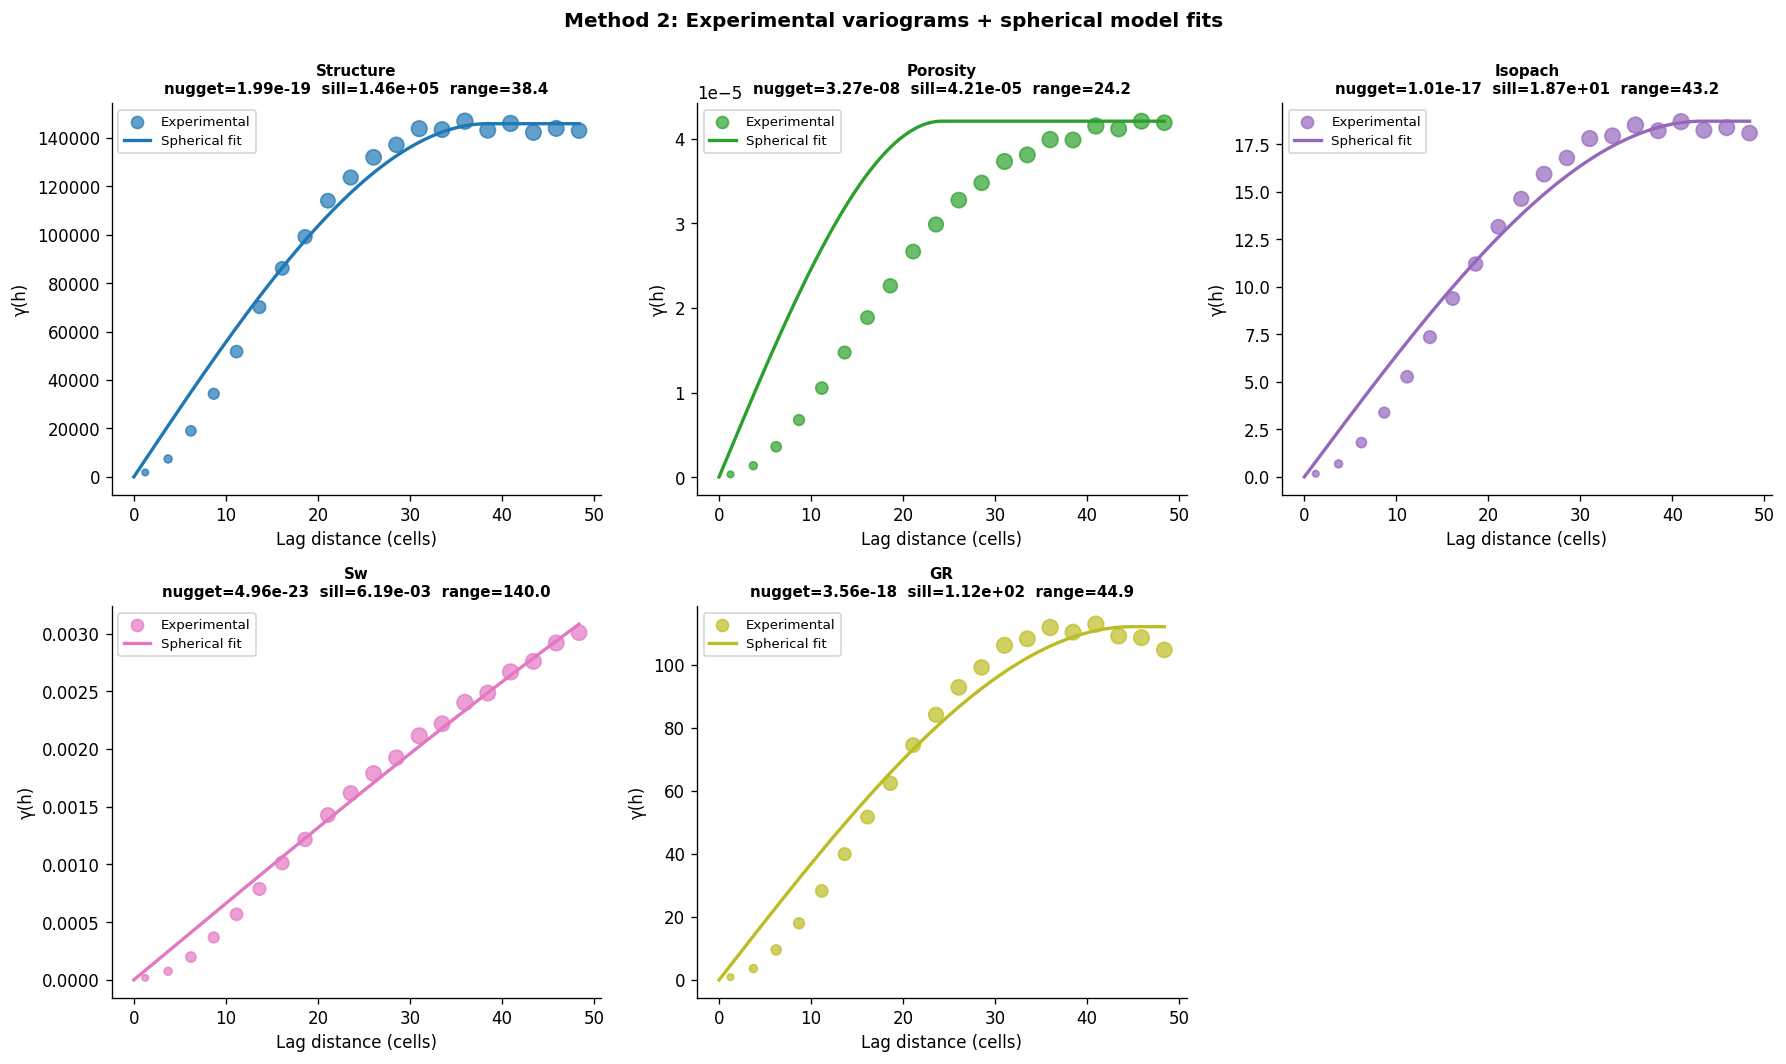

In [6]:
def experimental_variogram(grid, n_lags=20, max_lag_frac=0.45):
    """Compute isotropic experimental variogram."""
    flat = grid.ravel()
    rng  = np.random.default_rng(1)
    idx  = rng.choice(len(flat), size=min(2000, len(flat)), replace=False)
    r_idx, c_idx = np.unravel_index(idx, grid.shape)
    coords = np.stack([r_idx, c_idx], axis=1).astype(float)
    vals   = flat[idx]
    dists  = squareform(pdist(coords))
    max_d  = dists.max() * max_lag_frac
    lags   = np.linspace(0, max_d, n_lags+1)
    gamma  = []
    counts = []
    for lo, hi in zip(lags[:-1], lags[1:]):
        mask = (dists > lo) & (dists <= hi)
        if mask.sum() < 5:
            gamma.append(np.nan); counts.append(0); continue
        i_idx, j_idx = np.where(mask)
        diffs = vals[i_idx] - vals[j_idx]
        gamma.append(0.5 * np.mean(diffs**2))
        counts.append(mask.sum())
    centers = (lags[:-1] + lags[1:]) / 2
    return centers, np.array(gamma), np.array(counts)

def spherical_model(h, nugget, sill, rang):
    """Spherical variogram model."""
    h = np.asarray(h, float)
    out = np.where(
        h <= rang,
        nugget + (sill - nugget) * (1.5*(h/rang) - 0.5*(h/rang)**3),
        sill
    )
    return out

fit_results = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, grid), col in zip(axes, maps.items(), colors):
    h, gamma, cnt = experimental_variogram(grid)
    valid = ~np.isnan(gamma)
    ax.scatter(h[valid], gamma[valid], s=cnt[valid]/cnt[valid].max()*80+10,
               color=col, alpha=0.7, zorder=3, label='Experimental')
    try:
        p0 = [gamma[valid].min()*0.1, gamma[valid].max(), h[valid].max()*0.5]
        popt, _ = curve_fit(spherical_model, h[valid], gamma[valid],
                            p0=p0, maxfev=5000,
                            bounds=([0,0,1],[np.inf,np.inf,np.inf]))
        h_fit = np.linspace(0, h[valid].max(), 200)
        ax.plot(h_fit, spherical_model(h_fit, *popt), '-', color=col,
                linewidth=2, label='Spherical fit')
        fit_results[name] = dict(nugget=popt[0], sill=popt[1], range=popt[2])
        title_str = f'{name}' + chr(10) + f'nugget={popt[0]:.2e}  sill={popt[1]:.2e}  range={popt[2]:.1f}'
        ax.set_title(title_str, fontsize=9, fontweight='bold')
    except Exception:
        fit_results[name] = dict(nugget=np.nan, sill=np.nan, range=np.nan)
        ax.set_title(f'{name} (fit failed)', fontsize=9)
    ax.set_xlabel('Lag distance (cells)')
    ax.set_ylabel('γ(h)')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Method 2: Experimental variograms + spherical model fits', fontweight='bold')
plt.tight_layout()
plt.savefig('02_variograms.png', dpi=130, bbox_inches='tight')
plt.show()


In [7]:
# Summary table of variogram parameters
vario_df = pd.DataFrame(fit_results).T
vario_df.index.name = 'Property'
print("Variogram parameters:")
print(vario_df.round(4).to_string())
vario_df


Variogram parameters:
           nugget         sill     range
Property                                
Structure     0.0  145914.3095   38.4493
Porosity      0.0       0.0000   24.2010
Isopach       0.0      18.7067   43.2146
Sw            0.0       0.0062  139.9537
GR            0.0     112.1687   44.8933


,nugget,sill,range
Property,,,
Structure,1.992340e-19,145914.309529,38.449331
Porosity,3.273345e-08,0.000042,24.200950
Isopach,1.013285e-17,18.706671,43.214553
Sw,4.958641e-23,0.006187,139.953723
GR,3.556932e-18,112.168737,44.893324


---
## Method 3 — Principal Component Analysis (PCA)

Stack all five property grids into a node-by-property matrix, standardize, and decompose.
PC score maps reveal dominant modes of joint lateral variation.


In [8]:
# Build node × property matrix
X = np.column_stack([v.ravel() for v in maps.values()])   # (n_nodes, 5)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

pca    = PCA(n_components=5)
scores = pca.fit_transform(X_sc)     # (n_nodes, 5)
loads  = pca.components_             # (5, 5) — rows = PCs, cols = properties

print("Explained variance ratio per PC:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev*100:.1f}%  (cumulative: {pca.explained_variance_ratio_[:i+1].sum()*100:.1f}%)")


Explained variance ratio per PC:
  PC1: 90.5%  (cumulative: 90.5%)
  PC2: 6.9%  (cumulative: 97.4%)
  PC3: 2.1%  (cumulative: 99.5%)
  PC4: 0.4%  (cumulative: 99.9%)
  PC5: 0.1%  (cumulative: 100.0%)


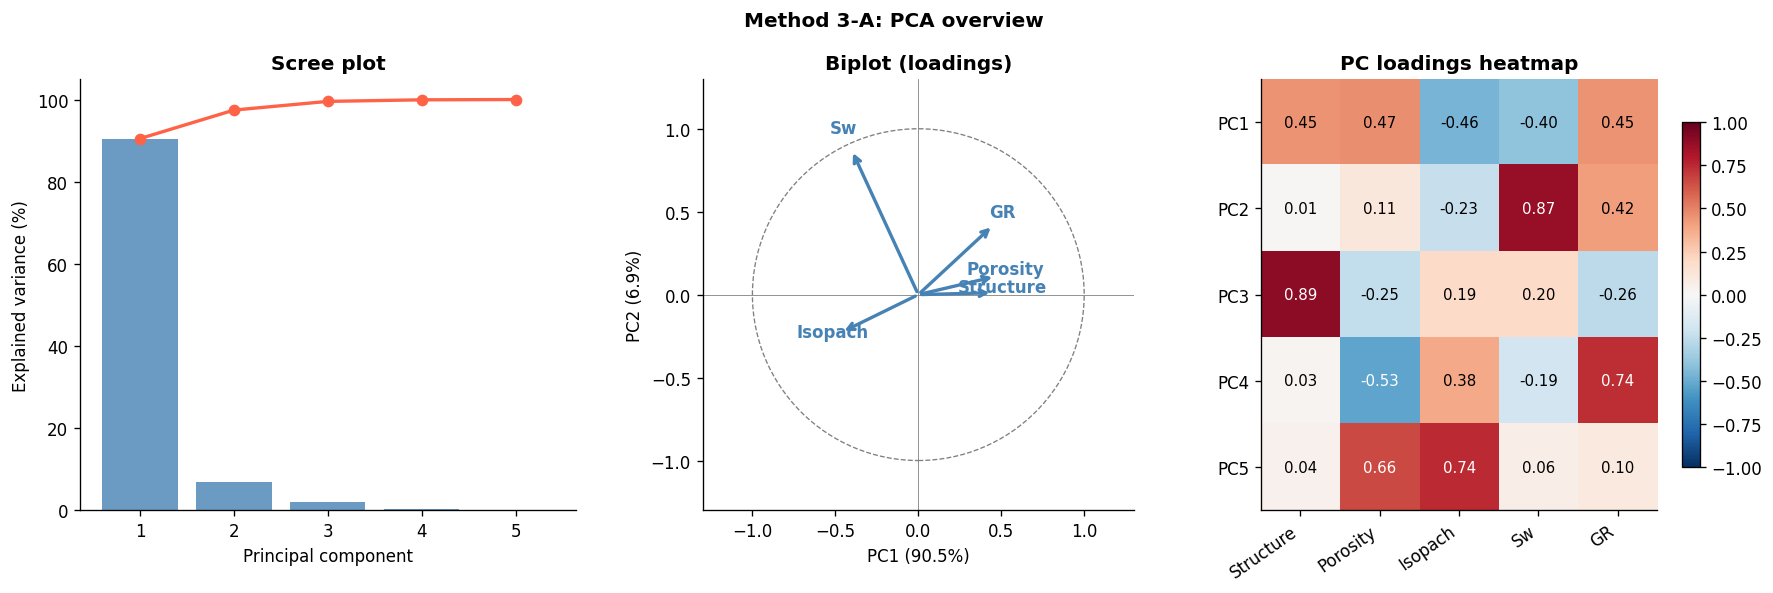

In [9]:
# ── PCA biplot + scree ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5))
gs  = GridSpec(1, 3, figure=fig)

# Scree plot
ax0 = fig.add_subplot(gs[0])
ax0.bar(range(1,6), pca.explained_variance_ratio_*100, color='steelblue', alpha=0.8)
ax0.plot(range(1,6), np.cumsum(pca.explained_variance_ratio_)*100,
         'o-', color='tomato', linewidth=2)
ax0.set_xlabel('Principal component')
ax0.set_ylabel('Explained variance (%)')
ax0.set_title('Scree plot', fontweight='bold')
ax0.set_xticks(range(1,6))

# Biplot (PC1 vs PC2 loadings)
ax1 = fig.add_subplot(gs[1])
for i, name in enumerate(props):
    ax1.annotate('', xy=(loads[0,i], loads[1,i]), xytext=(0,0),
                 arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
    ax1.text(loads[0,i]*1.12, loads[1,i]*1.12, name, fontsize=10, ha='center',
             color='steelblue', fontweight='bold')
circle = plt.Circle((0,0), 1, fill=False, color='gray', linestyle='--', linewidth=0.8)
ax1.add_patch(circle)
ax1.set_xlim(-1.3, 1.3); ax1.set_ylim(-1.3, 1.3)
ax1.axhline(0, color='gray', linewidth=0.5); ax1.axvline(0, color='gray', linewidth=0.5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('Biplot (loadings)', fontweight='bold')
ax1.set_aspect('equal')

# Loadings heatmap
ax2 = fig.add_subplot(gs[2])
im  = ax2.imshow(loads, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax2.set_xticks(range(len(props))); ax2.set_xticklabels(props, rotation=35, ha='right')
ax2.set_yticks(range(5)); ax2.set_yticklabels([f'PC{i+1}' for i in range(5)])
for i in range(5):
    for j in range(len(props)):
        ax2.text(j, i, f'{loads[i,j]:.2f}', ha='center', va='center', fontsize=9,
                 color='white' if abs(loads[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax2, shrink=0.8)
ax2.set_title('PC loadings heatmap', fontweight='bold')

plt.suptitle('Method 3-A: PCA overview', fontweight='bold')
plt.tight_layout()
plt.savefig('03a_pca_overview.png', dpi=130, bbox_inches='tight')
plt.show()


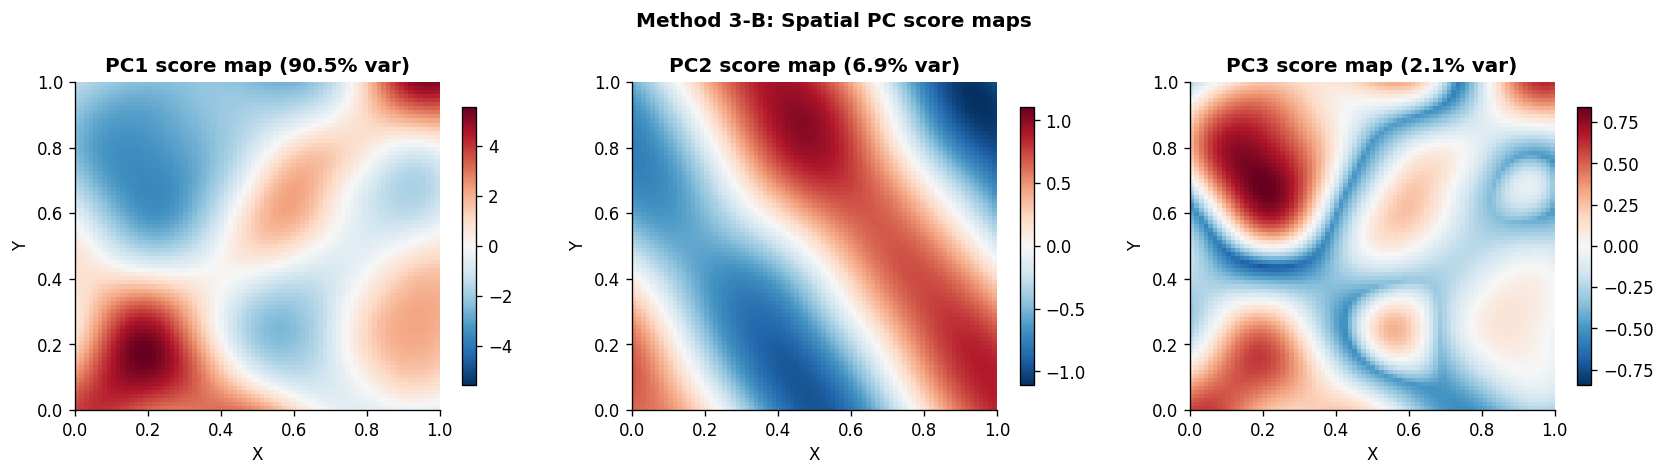

In [10]:
# ── PC score maps (spatial) ───────────────────────────────────────────────────
n_plot = 3
fig, axes = plt.subplots(1, n_plot, figsize=(14, 4))
for i, ax in enumerate(axes):
    pc_map = scores[:, i].reshape(GRID+1, GRID+1)
    vmax   = np.abs(pc_map).max()
    im = ax.imshow(pc_map, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, extent=[0,1,0,1], aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(f'PC{i+1} score map ({pca.explained_variance_ratio_[i]*100:.1f}% var)', fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.suptitle('Method 3-B: Spatial PC score maps', fontweight='bold')
plt.tight_layout()
plt.savefig('03b_pca_score_maps.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Method 4 — Moving-window statistics & trend surface analysis

### 4-A  Local mean, standard deviation, and coefficient of variation
A sliding kernel captures lateral heterogeneity; high CV flags rapid facies transitions.


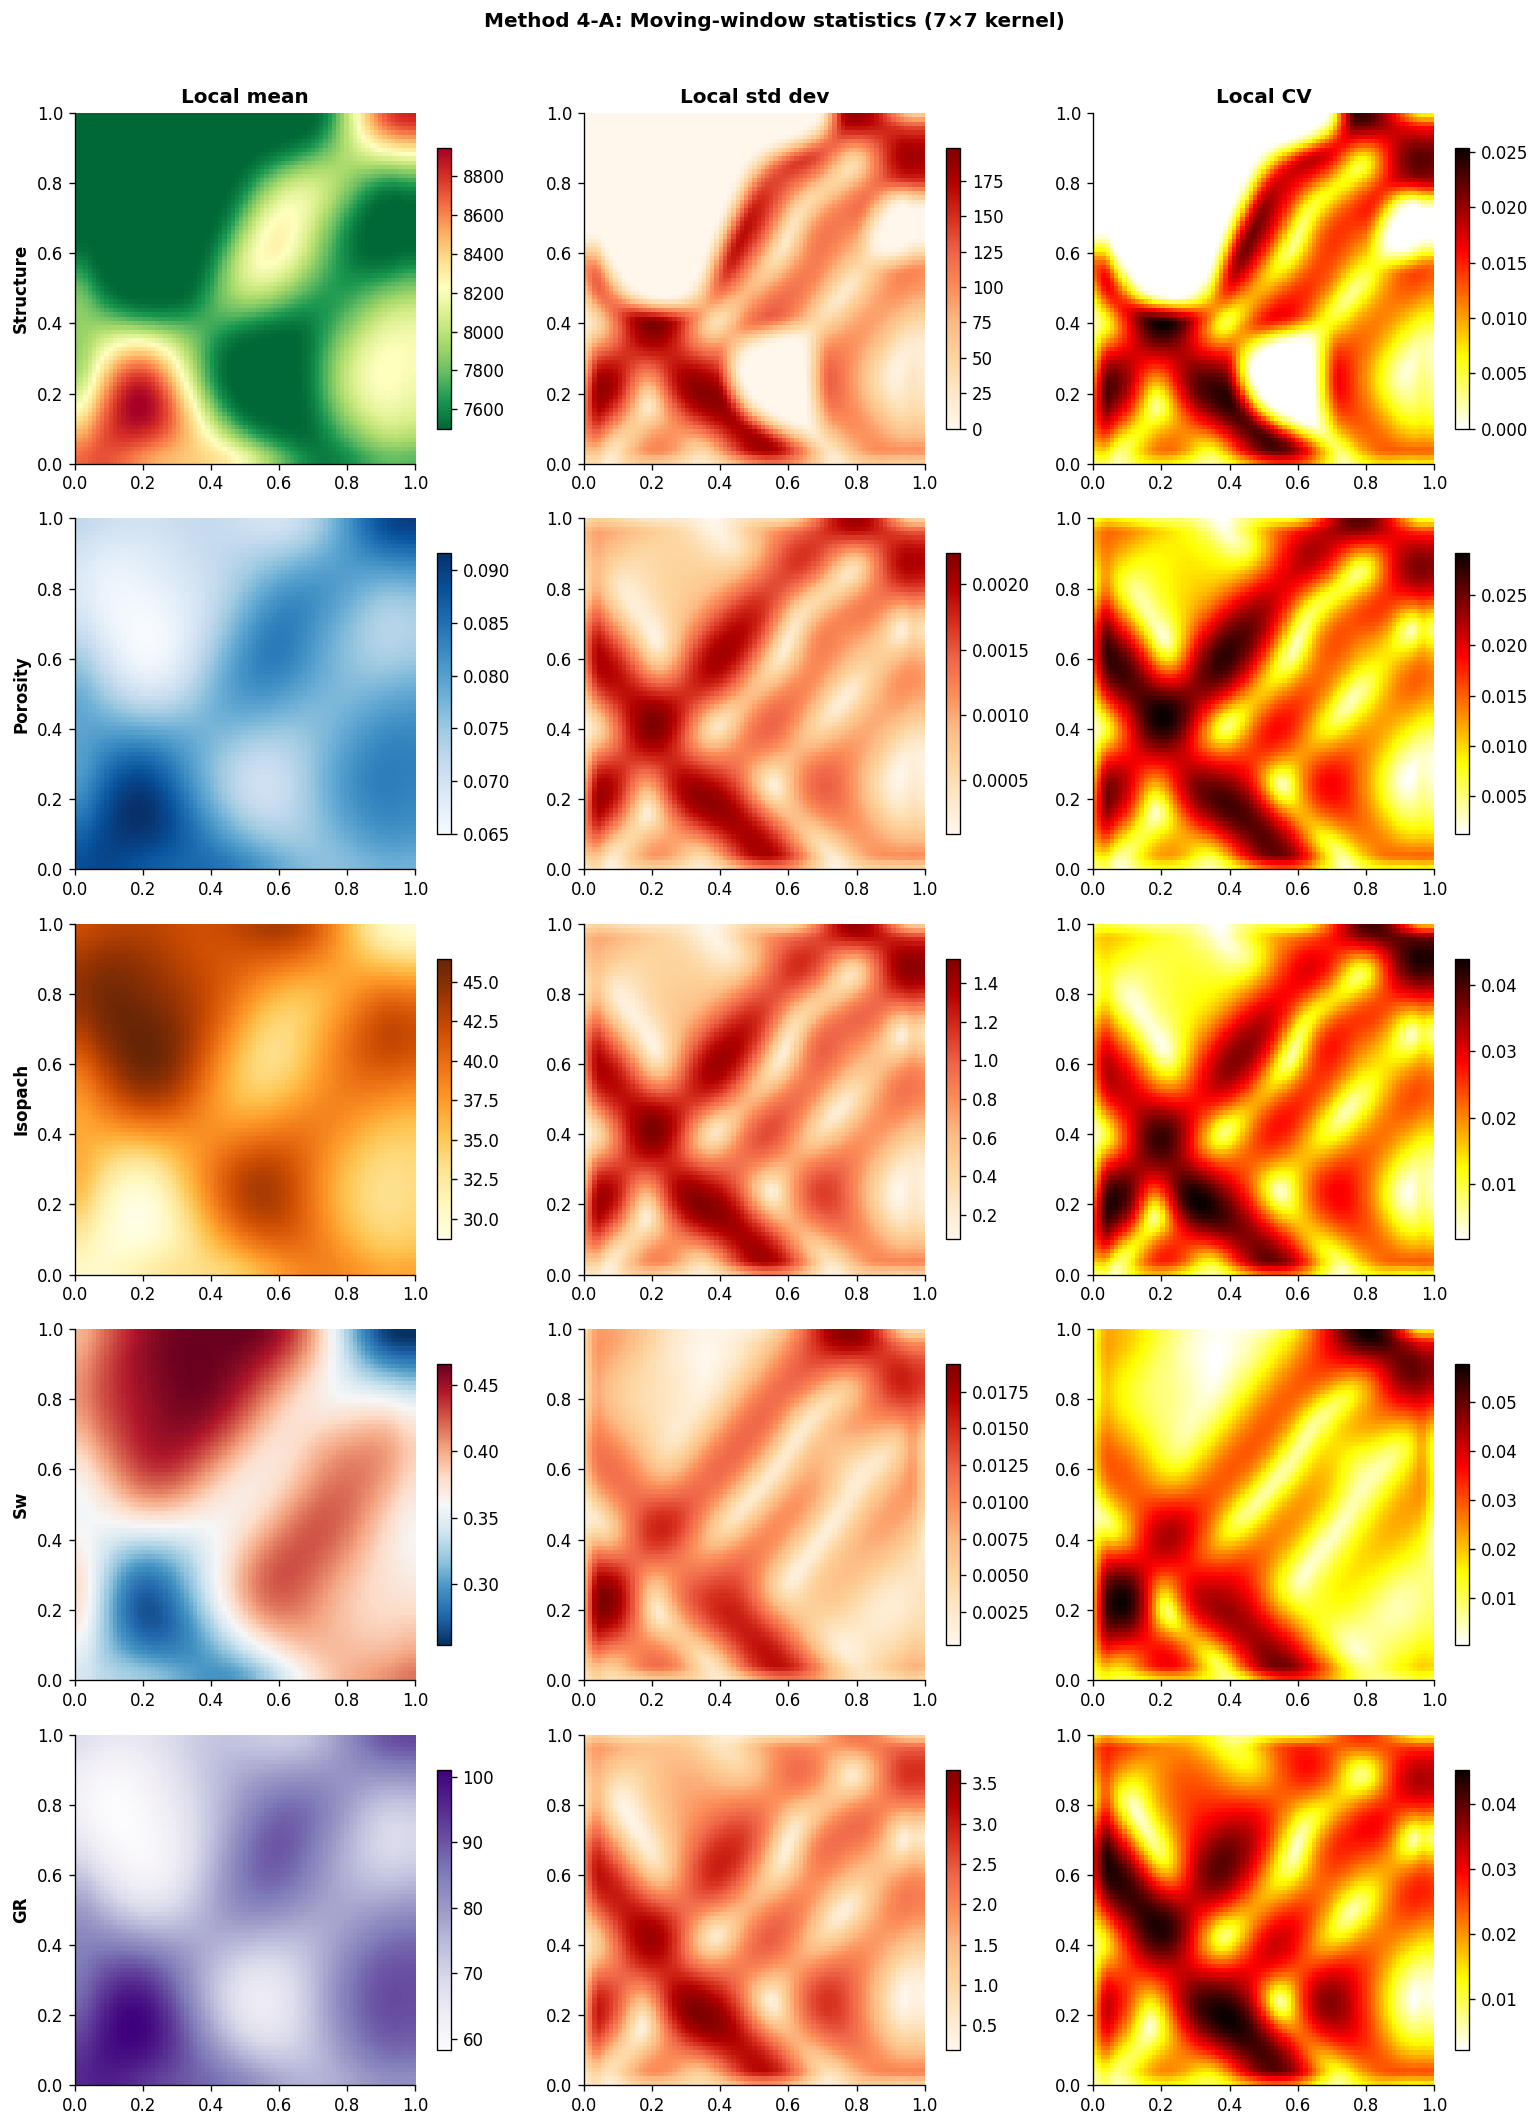

In [11]:
from scipy.ndimage import uniform_filter, generic_filter

def local_stats(grid, size=7):
    """Return local mean, std, CV using a square moving window."""
    local_mean = uniform_filter(grid.astype(float), size=size)
    local_sq   = uniform_filter(grid.astype(float)**2, size=size)
    local_var  = np.maximum(local_sq - local_mean**2, 0)
    local_std  = np.sqrt(local_var)
    with np.errstate(invalid='ignore', divide='ignore'):
        local_cv = np.where(local_mean != 0, local_std / np.abs(local_mean), 0)
    return local_mean, local_std, local_cv

fig, axes = plt.subplots(len(maps), 3, figsize=(13, 3.5*len(maps)))
stat_labels = ['Local mean', 'Local std dev', 'Local CV']

for row, (name, grid) in enumerate(maps.items()):
    lm, ls, lc = local_stats(grid, size=7)
    for col, (stat, label) in enumerate(zip([lm, ls, lc], stat_labels)):
        ax = axes[row, col]
        cmap = cmaps[name] if col == 0 else ('OrRd' if col == 1 else 'hot_r')
        im   = ax.imshow(stat, origin='lower', cmap=cmap,
                         extent=[0,1,0,1], aspect='auto')
        plt.colorbar(im, ax=ax, shrink=0.8)
        if row == 0:
            ax.set_title(label, fontweight='bold')
        if col == 0:
            ax.set_ylabel(name, fontweight='bold')

plt.suptitle('Method 4-A: Moving-window statistics (7×7 kernel)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04a_moving_window.png', dpi=130, bbox_inches='tight')
plt.show()


### 4-B  Polynomial trend surface & residual maps
Fit 2nd-order polynomial surfaces and map the residuals to isolate local anomalies from regional gradients.

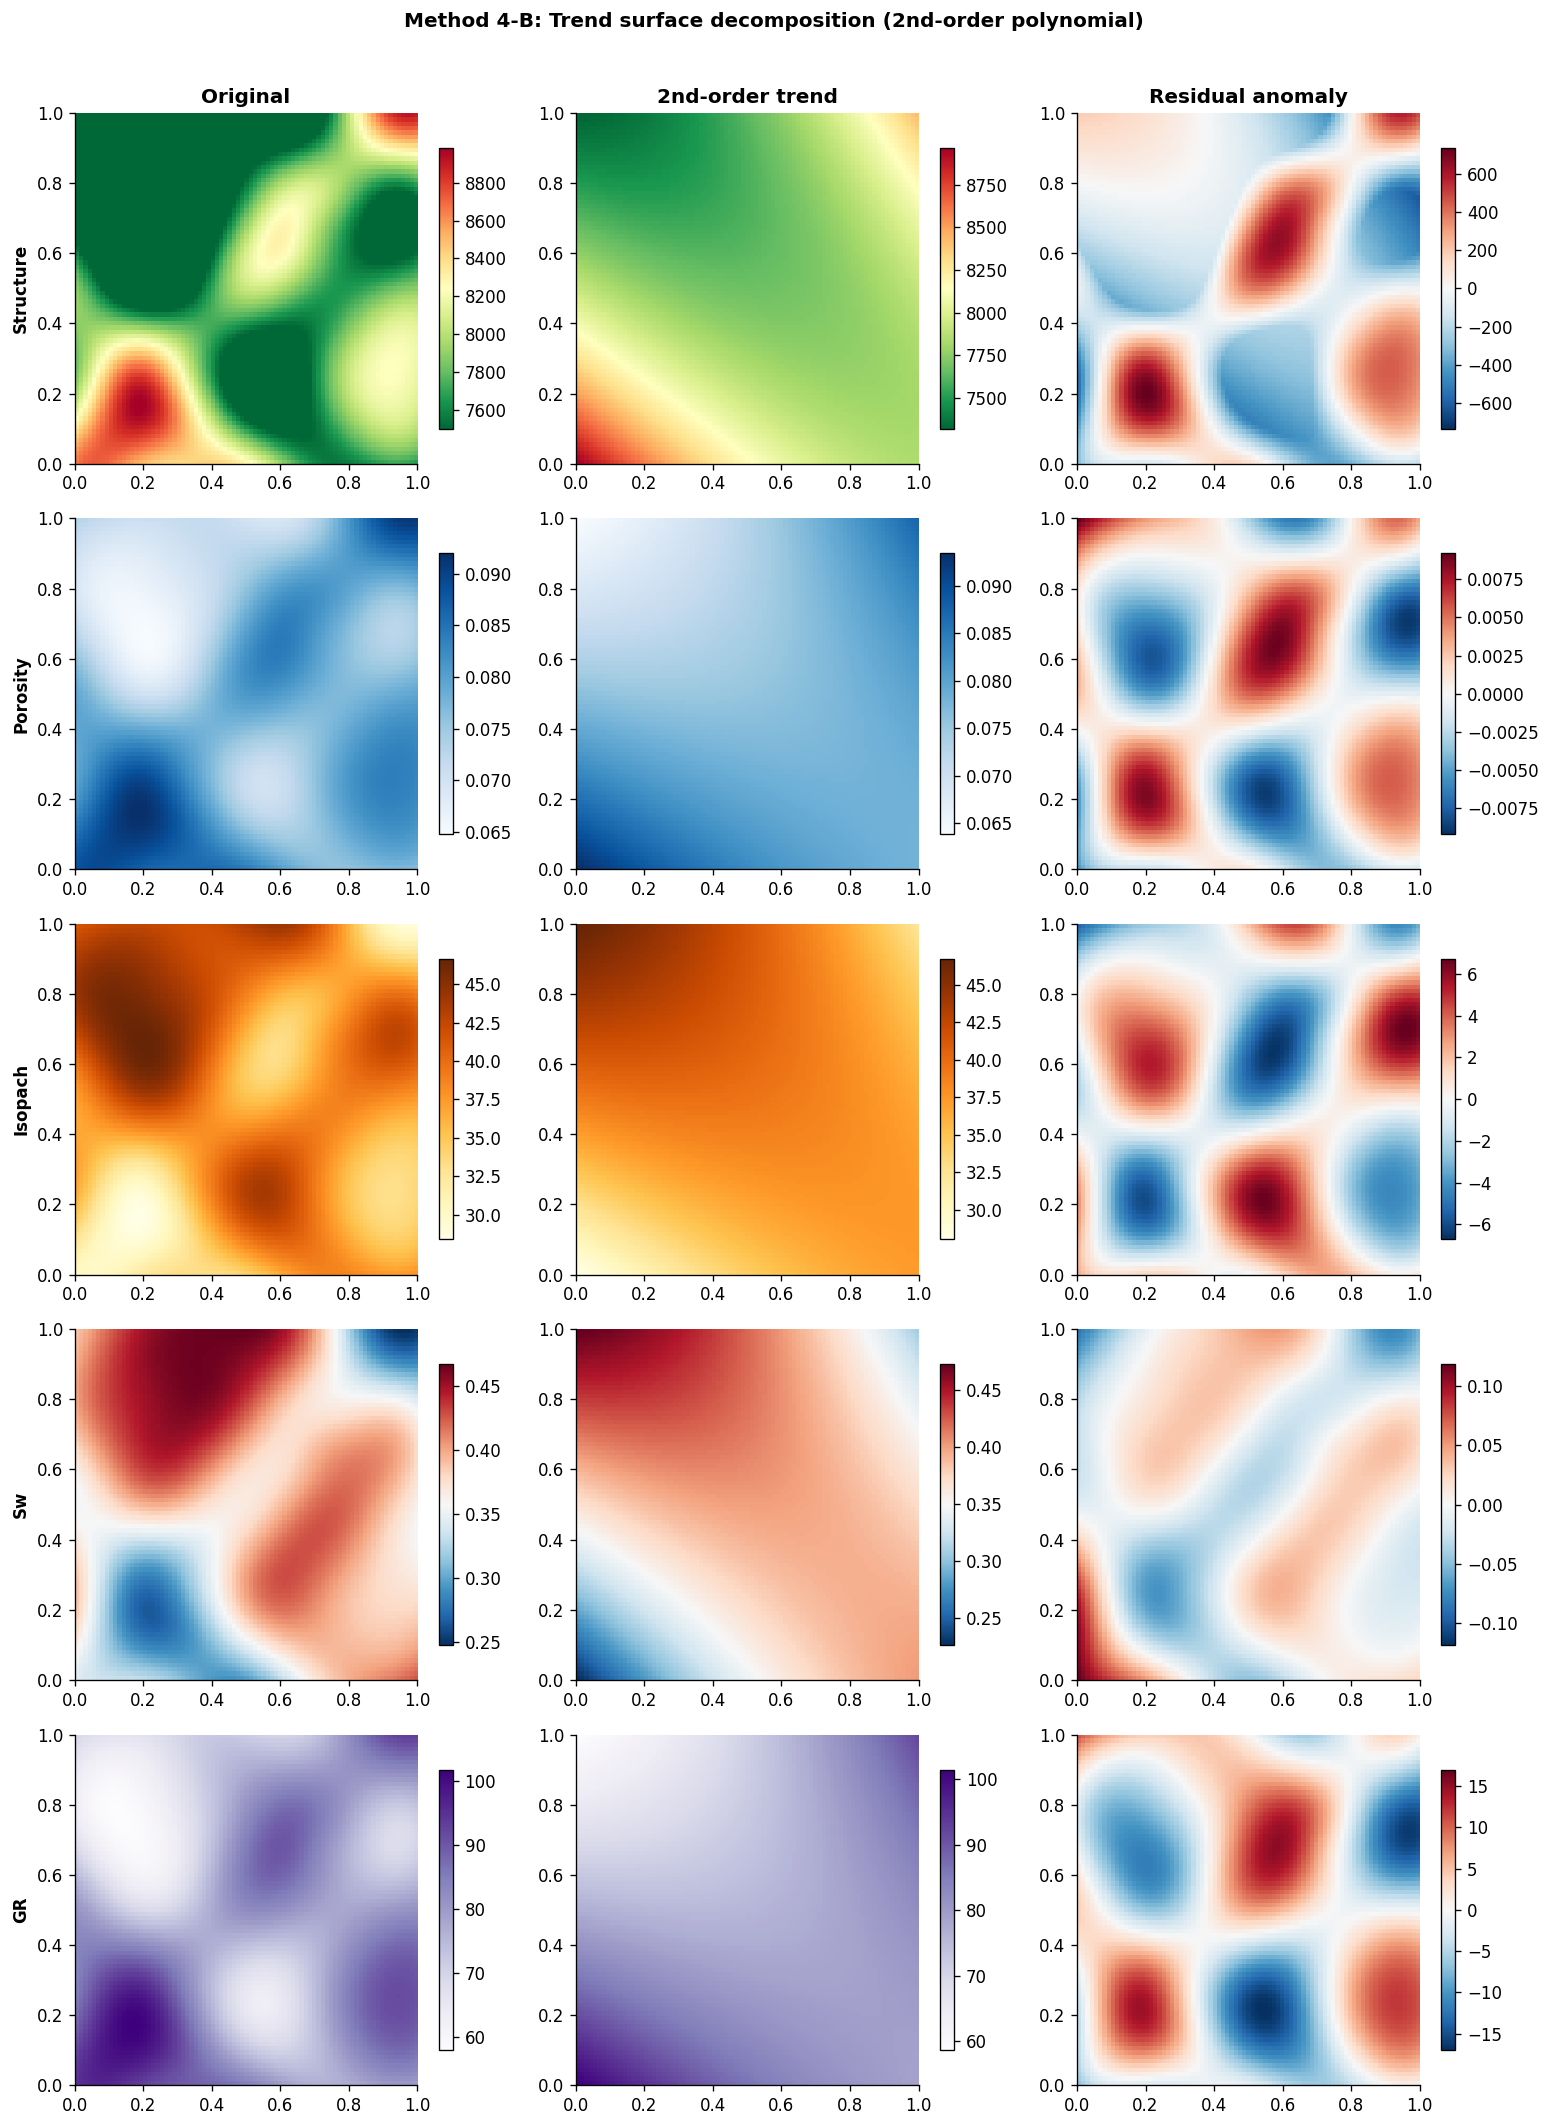

In [12]:
from numpy.polynomial import polynomial as P

def trend_surface(grid, degree=2):
    """Fit a 2-D polynomial trend surface and return trend + residual."""
    rows, cols = grid.shape
    r, c = np.meshgrid(np.linspace(-1,1,cols), np.linspace(-1,1,rows))
    # build Vandermonde matrix for 2-D polynomial
    feat_list = []
    for i in range(degree+1):
        for j in range(degree+1 - i):
            feat_list.append((r**i) * (c**j))
    A = np.column_stack([f.ravel() for f in feat_list])
    b = grid.ravel()
    coeff, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    trend = (A @ coeff).reshape(grid.shape)
    return trend, grid - trend

fig, axes = plt.subplots(len(maps), 3, figsize=(13, 3.5*len(maps)))

for row, (name, grid) in enumerate(maps.items()):
    trend, resid = trend_surface(grid, degree=2)
    vr = np.abs(resid).max()
    for col, (data, label, cmap) in enumerate([
        (grid,  'Original',          cmaps[name]),
        (trend, '2nd-order trend',   cmaps[name]),
        (resid, 'Residual anomaly',  'RdBu_r')
    ]):
        ax = axes[row, col]
        kw = dict(vmin=-vr, vmax=vr) if col == 2 else {}
        im = ax.imshow(data, origin='lower', cmap=cmap,
                       extent=[0,1,0,1], aspect='auto', **kw)
        plt.colorbar(im, ax=ax, shrink=0.8)
        if row == 0:
            ax.set_title(label, fontweight='bold')
        if col == 0:
            ax.set_ylabel(name, fontweight='bold')

plt.suptitle('Method 4-B: Trend surface decomposition (2nd-order polynomial)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04b_trend_surface.png', dpi=130, bbox_inches='tight')
plt.show()


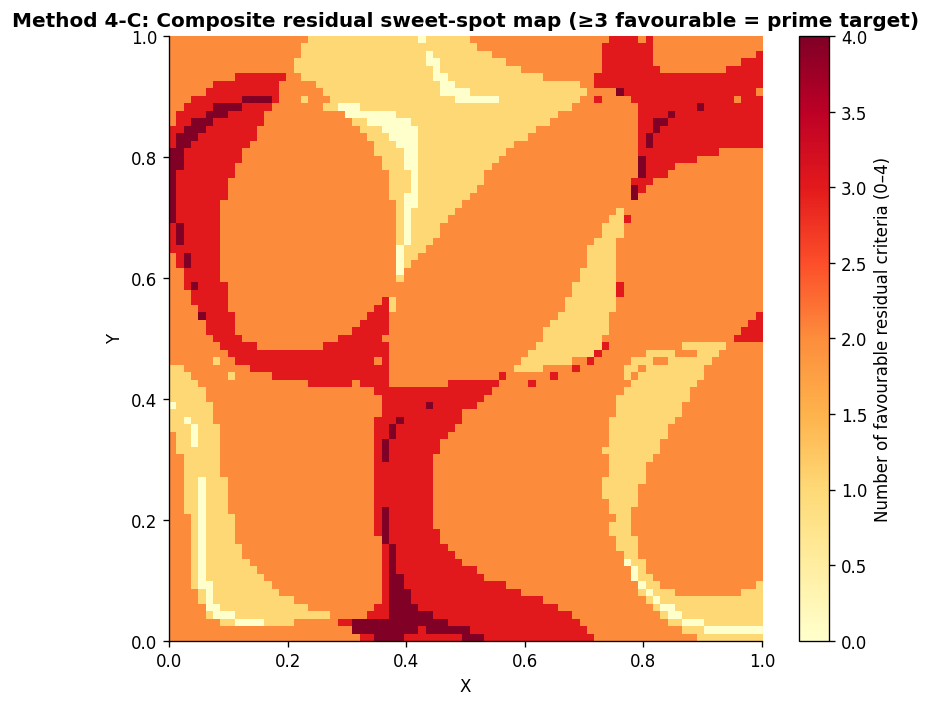

In [13]:
# ── Composite sweet-spot map from residuals ───────────────────────────────────
# High-quality nodes: porosity residual > 0, Sw residual < 0, GR residual < 0
_, resid_poro = trend_surface(poro, degree=2)
_, resid_sw   = trend_surface(sw,   degree=2)
_, resid_gr   = trend_surface(gr,   degree=2)
_, resid_iso  = trend_surface(iso,  degree=2)

sweet = (resid_poro > 0).astype(float) +         (resid_sw   < 0).astype(float) +         (resid_gr   < 0).astype(float) +         (resid_iso  > 0).astype(float)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sweet, origin='lower', cmap='YlOrRd',
               extent=[0,1,0,1], aspect='auto', vmin=0, vmax=4)
plt.colorbar(im, ax=ax, label='Number of favourable residual criteria (0–4)')
ax.set_title('Method 4-C: Composite residual sweet-spot map (≥3 favourable = prime target)', fontweight='bold')
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.tight_layout()
plt.savefig('04c_sweetspot_map.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Method 5 — K-means cluster analysis (electrofacies)

Partition the area into electrofacies zones by clustering the 5-property vector at each grid node.
We use the elbow method + silhouette score to select the optimal number of clusters.


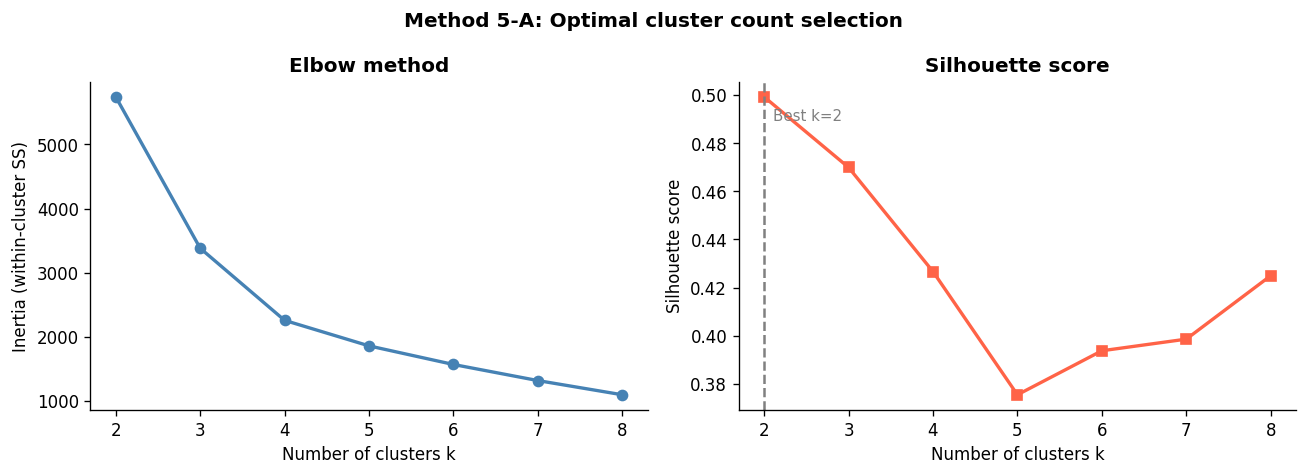

Optimal k by silhouette: 2


In [14]:
# ── Optimal k via elbow + silhouette ─────────────────────────────────────────
k_range  = range(2, 9)
inertias = []
silhouettes = []
rng_idx  = np.random.default_rng(7).choice(X_sc.shape[0], size=3000, replace=False)
X_sub    = X_sc[rng_idx]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_sub)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sub, labels, sample_size=1500))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of clusters k'); ax1.set_ylabel('Inertia (within-cluster SS)')
ax1.set_title('Elbow method', fontweight='bold')

ax2.plot(list(k_range), silhouettes, 's-', color='tomato', linewidth=2)
ax2.set_xlabel('Number of clusters k'); ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score', fontweight='bold')

best_k = list(k_range)[np.argmax(silhouettes)]
ax2.axvline(best_k, color='gray', linestyle='--')
ax2.text(best_k+0.1, max(silhouettes)*0.98, f'Best k={best_k}', fontsize=9, color='gray')

plt.suptitle('Method 5-A: Optimal cluster count selection', fontweight='bold')
plt.tight_layout()
plt.savefig('05a_cluster_selection.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Optimal k by silhouette: {best_k}")


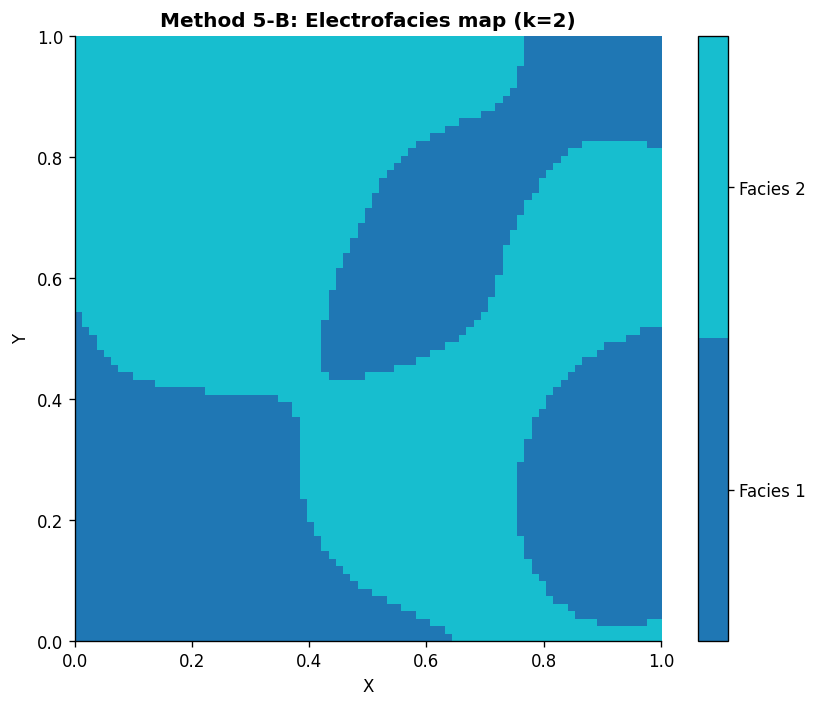

In [15]:
# ── Fit final K-means and map electrofacies ───────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=0, n_init=20)
labels_all = km_final.fit_predict(X_sc)
label_map  = labels_all.reshape(GRID+1, GRID+1)

cmap_facies = plt.cm.get_cmap('tab10', best_k)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(label_map, origin='lower', cmap=cmap_facies,
               extent=[0,1,0,1], aspect='auto', vmin=-0.5, vmax=best_k-0.5)
cbar = plt.colorbar(im, ax=ax, ticks=range(best_k))
cbar.set_ticklabels([f'Facies {i+1}' for i in range(best_k)])
ax.set_title(f'Method 5-B: Electrofacies map (k={best_k})', fontweight='bold')
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.tight_layout()
plt.savefig('05b_electrofacies_map.png', dpi=130, bbox_inches='tight')
plt.show()


In [16]:
# ── Cluster centroid table (mean property per facies) ─────────────────────────
centroids_sc = km_final.cluster_centers_            # standardized space
centroids    = scaler.inverse_transform(centroids_sc)  # original units
centroid_df  = pd.DataFrame(centroids, columns=props,
                             index=[f'Facies {i+1}' for i in range(best_k)])
centroid_df.index.name = 'Electrofacies'
print("Cluster centroids (original units):")
print(centroid_df.round(4).to_string())
centroid_df.round(4)


Cluster centroids (original units):
               Structure  Porosity  Isopach      Sw       GR
Electrofacies                                               
Facies 1       8191.7729    0.0830  34.4170  0.3466  87.1130
Facies 2       7557.6040    0.0729  41.3091  0.4120  71.2162


,Structure,Porosity,Isopach,Sw,GR
Electrofacies,,,,,
Facies 1,8191.7729,0.0830,34.4170,0.3466,87.1130
Facies 2,7557.6040,0.0729,41.3091,0.4120,71.2162


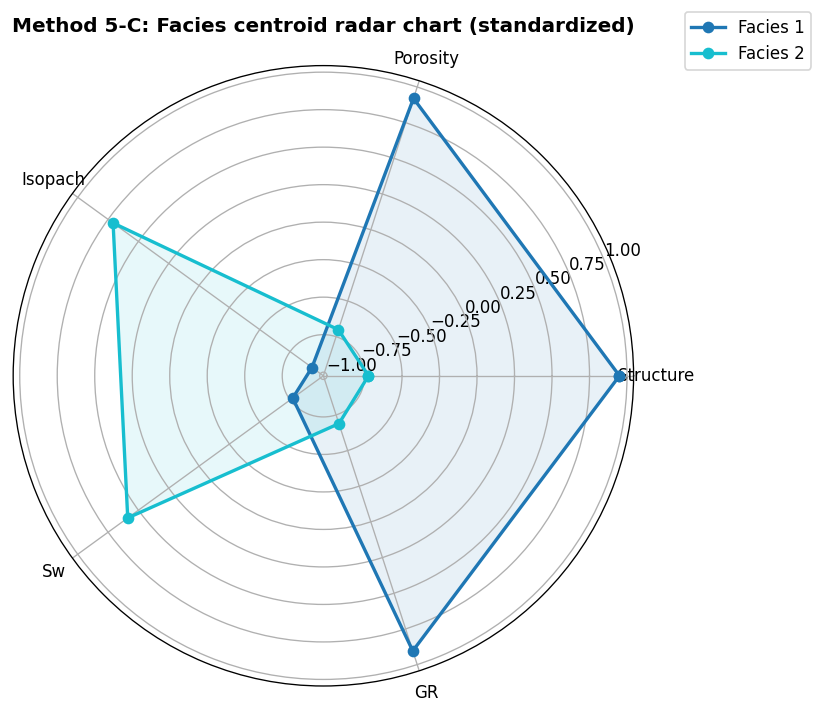

In [17]:
# ── Radar chart of cluster centroids ─────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

angles = np.linspace(0, 2*np.pi, len(props), endpoint=False).tolist()
angles += angles[:1]  # close

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, row in enumerate(centroids_sc):
    vals = row.tolist() + row[:1].tolist()
    ax.plot(angles, vals, 'o-', linewidth=2, label=f'Facies {i+1}',
            color=cmap_facies(i))
    ax.fill(angles, vals, alpha=0.10, color=cmap_facies(i))
ax.set_thetagrids(np.degrees(angles[:-1]), props)
ax.set_title('Method 5-C: Facies centroid radar chart (standardized)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('05c_radar_chart.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Summary of methods

| Method | Key outputs | Geological insight |
|--------|------------|-------------------|
| **1 — Cross-correlation & autocorrelogram** | Correlation matrix, Moran's I vs lag | Which properties co-vary; lateral continuity scale |
| **2 — Variogram modeling** | Nugget, sill, range per property | Heterogeneity structure; input to kriging/SGS |
| **3 — PCA** | Scree, biplot, PC score maps | Dominant joint variation modes; facies trend detection |
| **4 — Moving-window + trend surface** | Local CV maps, residual anomaly maps | Rapid change zones; regional vs local signals; sweet-spot ranking |
| **5 — K-means electrofacies** | Facies map, centroid table, radar chart | Petrophysical rock typing; lateral zonation without bias |

All five maps share the same spatial grid, so results are directly comparable and can be cross-overlaid for integrated interpretation.


In [18]:
print("Analysis complete. All figures saved as PNG in the working directory.")


Analysis complete. All figures saved as PNG in the working directory.
